# C02 · Code walkthrough: `powertrain/components/motor.py` and `generator.py` (electric machines)

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). This notebook covers the two machine classes, their loss models, their three mass models, the
`rubber_machine` factory, and how `examples/halo_sizing.py` turns rubber machines into whole units of real products.

| Module | Lines | What it holds |
|---|---|---|
| `powertrain/components/motor.py` | 252 | `SimpleMotorLossModel`, `McDonaldLossCoefficients`, `McDonaldMotorLossModel`, `TorqueDensityMassModel`, `DatabaseMassModel`, `UnitMachineMassModel`, `MotorResult`, `MotorLimits`, `Motor`, `rubber_machine` |
| `powertrain/components/generator.py` | 46 | `GeneratorResult`, `Generator` (reuses the motor's loss model and `MotorLimits`) |

**What they import:** `motor.py` imports only `dataclasses`, `typing.Any` and `aerosandbox.numpy` (for `np.softmax`).
`generator.py` imports `McDonaldMotorLossModel` and `MotorLimits` from `motor.py`. Neither imports anything else from
the package: they are leaves.

**Who imports them (grep):** `powertrain/ports.py` (port specs per class), `powertrain/compatibility.py`
(`isinstance` checks for envelopes and margins), `powertrain/topologies.py` (`rubber_machine` in
`build_series_hybrid_from_sizing`), `examples/halo_sizing.py`, `examples/series_hybrid_point*.py`, and tests
(`test_mcdonald_losses`, `test_torque_sizing`, `test_machine_database`, `test_components`, `test_thermal`,
`test_redundancy`, ...). `performance/flight_point.py` never imports them: it calls `motor_model.evaluate(...)`
on whatever component the topology holds (duck typing).

**Run time:** under a minute. The sized aircraft is rebuilt with numbers, plus two tiny `asb.Opti` solves.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import replace
from examples.halo_sizing import HaloRequirements, build_halo_aircraft

ref, assumptions = baseline(), baseline_assumptions()
# The sized v3.6 aircraft, rebuilt with numbers (the solved design) instead of optimization variables.
aircraft = build_halo_aircraft(ref.design, HaloRequirements(), assumptions)
instances = aircraft.powertrain.topology.instances
motor = instances["motor"].component          # one lane motor (4 in the aircraft: 2 rotors x 2 lanes)
generator = instances["generator"].component  # one generator (2 in the aircraft)
print("motor     count", instances["motor"].count, "  generator count", instances["generator"].count)
print("unit counts (this solve, fixed):", ref.machine_units)

motor     count 4   generator count 2
unit counts (this solve, fixed): {'motor': (2.0, 2), 'generator': (3.0, 3)}


---
## 1. `motor.py` L1-24: module docstring and the quadratic loss model

In [2]:
show_source("src/aircraft_closure/powertrain/components/motor.py", 1, 24)

# src/aircraft_closure/powertrain/components/motor.py  lines 1-24
   1  """Motoring quadrant only: speed and torque >= 0, voltage > 0.
   2  
   3  Default losses: McDonald parametric model (AIAA 2015-1676); the quadratic
   4  `SimpleMotorLossModel` remains available as the simplest model.
   5  """
   6  from dataclasses import dataclass, field
   7  from typing import Any
   8  
   9  import aerosandbox.numpy as np
  10  
  11  
  12  @dataclass(frozen=True)
  13  class SimpleMotorLossModel:
  14      """Quadratic torque/speed losses; coefficients require calibration.
  15  
  16      Voltage is accepted so later loss maps can retain this operating interface.
  17      This approximation has no voltage-dependent losses or inverter model.
  18      """
  19      torque_loss_W_Nm2: float = 0.02
  20      speed_loss_W_s2_rad2: float = 0.001
  21  
  22      def evaluate(self, speed_rad_s, torque_Nm, voltage_V):
  23          return self.torque_loss_W_Nm2 * torque_Nm**2 + self.speed_los

**Line by line**

- **L1-5 docstring.** The motor is a *motoring-quadrant* model: speed ω ≥ 0, torque Q ≥ 0, voltage V > 0. There is no
  regeneration through a motor. The generating quadrant is a separate class (`generator.py`). The default loss
  model is McDonald (plan 005, `docs/decisions/005-mcdonald-motor-loss-model.md`).
- **L6-9 imports.** `aerosandbox.numpy as np` is the only numeric import. It dispatches to NumPy for floats and to
  CasADi for symbolic inputs, so every formula below works with design variables. In this file it is used only for
  `np.softmax` (L82, L142, L175).
- **L12-23 `SimpleMotorLossModel`.** Two coefficients:

$$P_{loss} = a\,Q^2 + b\,\omega^2,\qquad a = 0.02\ \mathrm{W/(N\,m)^2},\quad b = 0.001\ \mathrm{W\,s^2/rad^2}$$

  The Q² term stands for copper loss (Q is proportional to current, loss to I²R). The ω² term lumps the speed losses.
  The coefficients are not tied to any machine size, so the model does not scale with a rubber machine. It is kept
  under project rule 10 (keep the simplest model, `docs/CODING_CONVENTIONS.md`) and is used only by tests.
- **L22 `evaluate(speed_rad_s, torque_Nm, voltage_V)`.** Voltage is accepted and ignored (L16-17): every loss model
  has the same signature, so a later voltage-dependent model can be swapped in without touching `Motor`.
- **`frozen=True`** on every dataclass in the file: components are immutable values. A variant is made with
  `dataclasses.replace` (as `unit_machine` does in the Halo), never by mutation.

In [3]:
from aircraft_closure.powertrain.components.motor import SimpleMotorLossModel
simple = SimpleMotorLossModel()
print("simple loss at (400 rad/s, 200 N m):", simple.evaluate(400, 200, 800), "W")   # 0.02*200^2 + 0.001*400^2
check("SimpleMotorLossModel: 0.02*200^2 + 0.001*400^2 = 960 W", abs(simple.evaluate(400, 200, 800) - 960) < 1e-9)
check("SimpleMotorLossModel ignores voltage", simple.evaluate(400, 200, 100) == simple.evaluate(400, 200, 900))

simple loss at (400 rad/s, 200 N m): 960.0 W
PASS  SimpleMotorLossModel: 0.02*200^2 + 0.001*400^2 = 960 W
PASS  SimpleMotorLossModel ignores voltage


---
## 2. `motor.py` L26-63: the McDonald loss model (the default)

In [4]:
show_source("src/aircraft_closure/powertrain/components/motor.py", 26, 63)

# src/aircraft_closure/powertrain/components/motor.py  lines 26-63
  26  @dataclass(frozen=True)
  27  class McDonaldLossCoefficients:
  28      constant_W: Any
  29      linear_W_s_rad: Any
  30      cubic_W_s3_rad3: Any
  31      torque_W_Nm2: Any
  32  
  33  
  34  @dataclass(frozen=True)
  35  class McDonaldMotorLossModel:
  36      """Parametric loss model of McDonald, AIAA 2015-1676, eqs. 1-2.
  37  
  38      P_L = C0 + C1 w + C2 w^3 + C3 Q^2, with coefficients fixed by the speed,
  39      torque and value of peak efficiency and the parasite loss ratio k0 in
  40      [0, 1]. C0 is a constant (standstill) loss. Voltage is accepted to keep
  41      the machine interface stable; losses do not depend on it.
  42      """
  43      speed_peak_efficiency_rad_s: Any = 400.0
  44      torque_peak_efficiency_Nm: Any = 200.0
  45      efficiency_peak: Any = 0.96
  46      parasite_loss_ratio: Any = 0.5
  47  
  48      def coefficients(self):
  49          speed_rad_s = self.speed_pea

**Source:** McDonald, "Modeling of Electric Motor Driven Propellers for Conceptual Aircraft Design", AIAA 2015-1676,
eqs. 1-2. Adopted in plan 005 at the author's request.

- **L26-31 `McDonaldLossCoefficients`.** A plain container for C0..C3 with their units in the field names.
- **L34-46 parameters.** Four numbers define the whole loss map:
  ω̂ = `speed_peak_efficiency_rad_s` (rad/s), Q̂ = `torque_peak_efficiency_Nm` (N m), η̂ = `efficiency_peak`, and
  k0 = `parasite_loss_ratio` in [0, 1]. All typed `Any`: in the Halo, ω̂ and Q̂ are design variables.
- **L48-58 `coefficients()`.** With ℓ = (1 − η̂)/η̂ (L51), the loss is

$$P_L = C_0 + C_1\,\omega + C_2\,\omega^3 + C_3\,Q^2$$

$$C_0 = \frac{k_0\,\hat\omega\,\hat Q\,\ell}{6},\quad
C_1 = -\frac{3C_0}{2\hat\omega} + \frac{\hat Q\,\ell}{4},\quad
C_2 = \frac{C_0}{2\hat\omega^3} + \frac{\hat Q\,\ell}{4\hat\omega^2},\quad
C_3 = \frac{\hat\omega\,\ell}{2\hat Q}$$

  (L52, L55, L56, L57). Physical reading: C0 constant loss (present even at standstill), C1 ω friction and hysteresis,
  C2 ω³ windage and high-frequency eddy loss, C3 Q² copper loss.
- **Why these coefficients.** They are the unique choice that puts the efficiency maximum at (ω̂, Q̂) with value η̂.
  At the peak, loss = ℓ ω̂ Q̂ so that η = ω̂Q̂/(ω̂Q̂ + ℓω̂Q̂) = 1/(1 + ℓ) = η̂. Zero gradient of η is the same as
  zero gradient of loss/power there. The torque condition gives C3 Q̂² = ℓω̂Q̂/2 (half the loss is copper). The speed
  terms carry the other half, 2·ℓω̂Q̂/4, whatever k0 is. That is why **k0 has no effect at ω̂** (plan 005): it only
  shifts loss between the constant and the speed terms away from the peak speed.
- **C1 ≥ 0.** Substituting C0: C1 = Q̂ℓ(1 − k0)/4 ≥ 0 for k0 ≤ 1 (plan 005). All coefficients are then non-negative,
  so the loss is positive everywhere in the motoring quadrant.
- **L60-63 `evaluate`.** Recomputes the coefficients on every call. They are cheap expressions, and recomputing keeps
  the dataclass stateless and symbolic-safe (no cached floats from a previous design).
- **Scaling.** Every coefficient is homogeneous in (ω̂, Q̂): doubling Q̂ doubles C0, C1 and C2 and halves C3. Loss
  therefore scales with the machine rating. That is the property a rubber machine needs.

**Run it** on the sized lane motor (its ω̂ and Q̂ are the solved design variables):

In [5]:
lm = motor.loss_model
c = lm.coefficients()
w_hat, q_hat, eta_hat, k0 = (lm.speed_peak_efficiency_rad_s, lm.torque_peak_efficiency_Nm, lm.efficiency_peak,
                             lm.parasite_loss_ratio)
ell = (1 - eta_hat) / eta_hat
print(f"motor peak point: w_hat {w_hat:.2f} rad/s ({w_hat / u.rpm:.0f} rpm), Q_hat {q_hat:.1f} N m, "
      f"eta_hat {eta_hat}, k0 {k0}")
print(f"C0 {c.constant_W:.1f} W, C1 {c.linear_W_s_rad:.3f} W s/rad, C2 {c.cubic_W_s3_rad3:.4e} W s3/rad3, "
      f"C3 {c.torque_W_Nm2:.5f} W/(N m)2")

eta = lambda m, w, q: w * q / (w * q + m.loss_model.evaluate(w, q, 800.0))
h = 1e-4
grad_w = (eta(motor, w_hat * (1 + h), q_hat) - eta(motor, w_hat * (1 - h), q_hat)) / (2 * h * w_hat)
grad_q = (eta(motor, w_hat, q_hat * (1 + h)) - eta(motor, w_hat, q_hat * (1 - h))) / (2 * h * q_hat)
print(f"eta at the peak {eta(motor, w_hat, q_hat):.6f}; d eta/dw {grad_w:.2e} per rad/s, d eta/dQ {grad_q:.2e} per N m")
check("McDonald: efficiency at (w_hat, Q_hat) equals eta_hat", abs(eta(motor, w_hat, q_hat) - eta_hat) < 1e-12)
check("McDonald: the peak is stationary (gradient ~ 0)", abs(grad_w) < 1e-9 and abs(grad_q) < 1e-9)
check("McDonald: C1 = Q_hat l (1 - k0) / 4", abs(c.linear_W_s_rad - q_hat * ell * (1 - k0) / 4) < 1e-9)
check("McDonald: copper loss is half the loss at the peak",
      abs(c.torque_W_Nm2 * q_hat**2 - 0.5 * ell * w_hat * q_hat) < 1e-6)
from aircraft_closure.powertrain.components.motor import McDonaldMotorLossModel
k0_free = [McDonaldMotorLossModel(w_hat, q_hat, eta_hat, k).evaluate(w_hat, 0.7 * q_hat, 800) for k in (0.0, 0.5, 1.0)]
k0_off = [McDonaldMotorLossModel(w_hat, q_hat, eta_hat, k).evaluate(0.5 * w_hat, q_hat, 800) for k in (0.0, 0.5, 1.0)]
print("loss at w_hat for k0 = 0, 0.5, 1:", [round(x, 3) for x in k0_free], "W")
print("loss at w_hat/2 for k0 = 0, 0.5, 1:", [round(x, 1) for x in k0_off], "W")
check("McDonald: k0 has no effect at w_hat", max(k0_free) - min(k0_free) < 1e-6)
double = McDonaldMotorLossModel(w_hat, 2 * q_hat, eta_hat, k0)
check("McDonald: doubling Q_hat doubles loss at (w, 2Q)",
      abs(double.evaluate(150.0, 2 * 1000.0, 800) - 2 * lm.evaluate(150.0, 1000.0, 800)) < 1e-6)

motor peak point: w_hat 204.45 rad/s (1952 rpm), Q_hat 1616.9 N m, eta_hat 0.96, k0 0.5
C0 1147.9 W, C1 8.422 W s/rad, C2 4.7010e-04 W s3/rad3, C3 0.00263 W/(N m)2
eta at the peak 0.960000; d eta/dw 1.10e-12 per rad/s, d eta/dQ 1.19e-13 per N m
PASS  McDonald: efficiency at (w_hat, Q_hat) equals eta_hat
PASS  McDonald: the peak is stationary (gradient ~ 0)
PASS  McDonald: C1 = Q_hat l (1 - k0) / 4
PASS  McDonald: copper loss is half the loss at the peak
loss at w_hat for k0 = 0, 0.5, 1: [10261.853, 10261.853, 10261.853] W
loss at w_hat/2 for k0 = 0, 0.5, 1: [9039.4, 9398.1, 9756.8] W
PASS  McDonald: k0 has no effect at w_hat
PASS  McDonald: doubling Q_hat doubles loss at (w, 2Q)


The efficiency map of the sized lane motor, with the healthy mission operating points from the baseline
(`ref.segments`: per-lane motor speed and torque) and the unit limits (2,500 rpm, 2 × 1,500 N m):

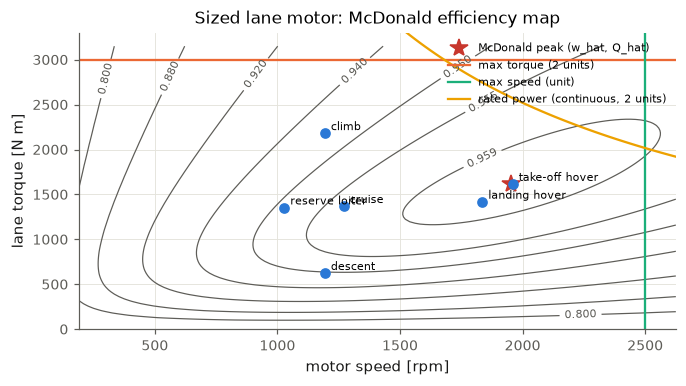

take-off hover   w  205.2 rad/s  Q  1615.9 N m  eta 0.9600
climb            w  124.9 rad/s  Q  2181.6 N m  eta 0.9457
cruise           w  133.0 rad/s  Q  1370.3 N m  eta 0.9563
reserve loiter   w  107.6 rad/s  Q  1354.1 N m  eta 0.9512
descent          w  124.9 rad/s  Q   624.2 N m  eta 0.9496
landing hover    w  192.2 rad/s  Q  1417.6 N m  eta 0.9598
bus-out hover: worst lane torque / max torque 1.000000, binding ('bus-out hover 1/3: motor torque_Nm',)
PASS  Healthy points inside the 2-unit torque limit; the bus-out hover reaches it


In [6]:
w_grid = np.linspace(20, 1.05 * motor.max_speed_rad_s, 120)
q_grid = np.linspace(50, 1.05 * motor.max_torque_Nm, 120)
W, Q = np.meshgrid(w_grid, q_grid)
E = W * Q / (W * Q + lm.evaluate(W, Q, 800.0))
fig, ax = plt.subplots(figsize=(7, 3.5))
cs = ax.contour(W / u.rpm, Q, E, levels=[0.80, 0.88, 0.92, 0.94, 0.95, 0.955, 0.959], colors=ink_muted, linewidths=0.8)
ax.clabel(cs, fontsize=7)
ax.plot(w_hat / u.rpm, q_hat, "*", color=red, ms=12, label="McDonald peak (w_hat, Q_hat)")
for s in ref.segments:
    ax.plot(s["speed_motor_rad_s"] / u.rpm, s["torque_motor_Nm"], "o", color=blue)
    ax.annotate(s["label"], (s["speed_motor_rad_s"] / u.rpm, s["torque_motor_Nm"]), fontsize=7,
                xytext=(4, 2), textcoords="offset points")
ax.axhline(motor.max_torque_Nm, color=orange, label="max torque (2 units)")
ax.axvline(motor.max_speed_rad_s / u.rpm, color=aqua, label="max speed (unit)")
P = motor.power_rated_W
ax.plot(w_grid / u.rpm, P / w_grid, color=yellow, label="rated power (continuous, 2 units)")
ax.set_ylim(0, 1.1 * motor.max_torque_Nm); ax.set_xlabel("motor speed [rpm]"); ax.set_ylabel("lane torque [N m]")
ax.set_title("Sized lane motor: McDonald efficiency map"); ax.legend(fontsize=7, loc="upper right")
apply_style(); plt.show()
for s in ref.segments:
    print(f"{s['label']:<16} w {s['speed_motor_rad_s']:6.1f} rad/s  Q {s['torque_motor_Nm']:7.1f} N m  "
          f"eta {eta(motor, s['speed_motor_rad_s'], s['torque_motor_Nm']):.4f}")
bus_out = next(f for f in ref.failure_cases if f["label"] == "bus-out hover")
print(f"bus-out hover: worst lane torque / max torque {bus_out['torque_lane_to_max']:.6f}, binding {bus_out['binding']}")
check("Healthy points inside the 2-unit torque limit; the bus-out hover reaches it",
      max(s["torque_motor_Nm"] for s in ref.segments) < motor.max_torque_Nm
      and abs(bus_out["torque_lane_to_max"] - 1) < 1e-6)

Reading it: the optimizer placed the peak (red star) on the take-off hover point (205 rad/s, 1,616 N m), the point
with the highest per-lane power. Climb is the torque-heavy point (2,182 N m at a slow rotor: the "torque trap" of
plan 018). All healthy points sit well inside the two-unit limits. The machine is sized by a failure case: in the
bus-out hover one lane carries the rotor and reaches 100 % of max torque (`ref.failure_cases`, binding
"bus-out hover 1/3: motor torque_Nm").

---
## 3. `motor.py` L66-83: `TorqueDensityMassModel` (Tier 13, plan 018)

In [7]:
show_source("src/aircraft_closure/powertrain/components/motor.py", 66, 83)

# src/aircraft_closure/powertrain/components/motor.py  lines 66-83
  66  @dataclass(frozen=True)
  67  class TorqueDensityMassModel:
  68      """Machine mass from peak torque, with a specific-power cap at high speed (Tier 13, plan 018).
  69  
  70      mass = softmax(max_torque / torque_density, power_rated / specific_power_max): electromagnetic
  71      machine mass scales with rotor volume, i.e. torque, until high speed makes a power-density limit bind.
  72      Defaults: about 15 N.m/kg (magniX magni650: 3,216 N.m peak, 206 kg; magni350: 1,608 N.m, 128 kg; both
  73      including inverters and HV cables), and 10 kW/kg as a conventional high-speed cap (NASA's partially
  74      superconducting HEMM targets 16 kW/kg electromagnetic). The smooth maximum overestimates the exact one by
  75      at most smoothing_kg x ln 2.
  76      """
  77      torque_density_Nm_kg: Any = 15.0
  78      specific_power_max_W_kg: Any = 10000.0
  79      smoothing_kg: Any = 2.0
  80  
  81      def

- **L68-75 docstring, the physics.** Electromagnetic torque is air-gap shear stress × rotor surface × radius, so at a
  fixed technology level (shear stress limited thermally and magnetically) active mass scales with torque, not power.
  At fixed power a faster machine needs less torque and is lighter, until a specific-power limit binds (losses and
  rotor stress grow with speed). This is review item 2 of plan 018 ("mass is just power divided by a constant ...
  can't trade direct drive against geared drive"). It made motor speed and gear ratio real trades.
- **L77-79 defaults.** 15 N m/kg from magniX: magni650 3,216 N m / 206 kg = 15.6, magni350 1,608 N m / 128 kg = 12.6,
  both *including* inverters and HV cables. 10 kW/kg cap. `smoothing_kg` = 2 kg.
- **L81-83 `mass_kg(machine)`.**

$$m = \mathrm{softmax}\!\left(\frac{Q_{max}}{\tau},\ \frac{P_{rated}}{p_{max}};\ s\right)
= s\,\ln\!\left(e^{a/s} + e^{b/s}\right)$$

  The model reads `machine.max_torque_Nm` and `machine.power_rated_W`: it is a function of the machine's ratings,
  passed the machine itself (`self.mass_model.mass_kg(self)` in `Motor.get_mass`, L221). It does not care whether
  the machine is a `Motor` or a `Generator`.
- **Why softmax, and the bound.** `max(a, b)` has a kink where a = b; IPOPT's Newton steps chatter across it.
  log-sum-exp is smooth (C∞). Its error is largest when a = b: s·ln 2 = 1.39 kg for s = 2 kg (L74-75). It always
  overestimates, so it is conservative.

**Run it** on the sized lane motor's rubber ratings (the McDonald point with the Halo ratios, before units):

In [8]:
from aircraft_closure.powertrain.components.motor import (DatabaseMassModel, Motor, TorqueDensityMassModel,
                                                          UnitMachineMassModel, rubber_machine)
ratios = dict(torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5)      # halo_sizing.py L640
rubber = rubber_machine(Motor, w_hat, q_hat, **ratios)
tdm = TorqueDensityMassModel()
a_kg, b_kg = rubber.max_torque_Nm / 15.0, rubber.power_rated_W / 10000.0
m = float(tdm.mass_kg(rubber))
print(f"rubber lane motor: Q_max {rubber.max_torque_Nm:.0f} N m, P_rated {rubber.power_rated_W / 1e3:.0f} kW")
print(f"torque term {a_kg:.1f} kg, power term {b_kg:.1f} kg, softmax {m:.3f} kg")
check("TorqueDensity: softmax >= max of the two terms", m >= max(a_kg, b_kg))
check("TorqueDensity: overshoot <= smoothing x ln 2", m - max(a_kg, b_kg) <= 2.0 * np.log(2) + 1e-12)
tie = Motor(max_torque_Nm=1500.0, power_rated_W=1e6)                 # 100 kg either way: the worst case
check("TorqueDensity: overshoot is exactly 2 ln 2 when both terms are equal",
      abs(float(tdm.mass_kg(tie)) - 100.0 - 2 * np.log(2)) < 1e-9)

rubber lane motor: Q_max 4042 N m, P_rated 413 kW
torque term 269.5 kg, power term 41.3 kg, softmax 269.489 kg
PASS  TorqueDensity: softmax >= max of the two terms
PASS  TorqueDensity: overshoot <= smoothing x ln 2
PASS  TorqueDensity: overshoot is exactly 2 ln 2 when both terms are equal


---
## 4. `motor.py` L86-152: `DatabaseMassModel` (plan 033)

In [9]:
show_source("src/aircraft_closure/powertrain/components/motor.py", 86, 152)

# src/aircraft_closure/powertrain/components/motor.py  lines 86-152
  86  @dataclass(frozen=True)
  87  class DatabaseMassModel:
  88      """Machine mass from continuous torque, with torque density falling with base speed (plan 033).
  89  
  90      The machine's continuous torque is T_cont = ratio_torque_continuous_peak x max_torque_Nm. Its base speed is
  91      w = power_rated_W / T_cont. Bare-machine mass is
  92  
  93          softmax(T_cont / tau(w), power_rated_W / specific_power_max_W_kg),
  94          tau(w) = torque_density_ref_Nm_kg (w / speed_ref_rad_s)^(-exponent_speed),
  95  
  96      so mass falls as w^(exponent_speed - 1) at fixed power until the specific-power cap binds.
  97  
  98      Defaults:
  99      - tau_ref and the exponent are the least-squares fit to the 15 bare (or unknown-inverter) machines with
 100        published continuous ratings in data/machines/aerospace_motors.csv (`machine_database.fit_torque_density`);
 101        the RMS log residual is

**Docstring (L88-112)** is the model statement. The code is a direct transcription.

- **L114-122 parameters.** `torque_density_ref_Nm_kg` 11.79 at `speed_ref_rad_s` 500 with `exponent_speed` 0.271: the
  least-squares fit in log space over the 15 `fit` rows of `data/machines/aerospace_motors.csv`
  (`machine_database.fit_torque_density`; RMS log residual 0.37, a factor 1.45). 20 kW/kg cap, the Tier 15
  bare-machine assumption (L104: "the data do not constrain it").
- **L124-125 `torque_density_Nm_kg(w)`**:

$$\tau(\omega_b) = \tau_{ref}\left(\frac{\omega_b}{\omega_{ref}}\right)^{-a}$$

  Torque density falls with base speed: fast machines have smaller rotors and less room for copper per newton-metre.
- **L127-128 continuous torque** T_c = 0.5 Q_max. The fit is to *continuous* ratings, while a `Motor` carries a peak
  torque, so the ratio converts.
- **L130-131 base speed** ω_b = P_rated / T_c. With the Halo rubber ratios this is exactly ω̂ (L102-103):
  P_rated / (0.5 × 2.5 Q̂) = 1.25 ω̂ Q̂ / 1.25 Q̂ = ω̂.
- **L133-137 `count_stacks`**: a relaxed (continuous) stack count, T_c / T_stack_max, or 1.0 without a per-stack
  limit. It only multiplies `mass_overhead_stack_kg` (L144). Stacking does not change the fitted mass, because that
  mass is linear in torque at fixed speed: n stacks of T weigh what one machine of nT weighs (L110-112).
- **L139-144 `mass_bare_kg`**: softmax of the torque-density mass and the power-cap mass, plus the stack overheads.
  At fixed power, T_c = P/ω_b, so

$$m \propto \frac{P/\omega_b}{\omega_b^{-a}} = P\,\omega_b^{\,a-1} = P\,\omega_b^{-0.729}$$

  (L96). Mass falls with speed, but slower than with the speed-independent `TorqueDensityMassModel` (exponent −1).
  That slower fall is what removed the rubber model's 36:1 gear ratio artefact (plan 033).
- **L146-149 `mass_inverter_kg`**: None (default) is a bare machine, the inverter being its own Tier 15 component.
  A value adds P_rated / p_inv (an integrated drive). The same pattern recurs in `UnitMachineMassModel`.
- **L151-152 `mass_kg`** = bare + inverter. This is the interface every mass model exposes.

**In the Halo** `DatabaseMassModel` is selected by `machine_mass_model="database"` (halo_sizing.py L657-662). The
default since plan 035 is `"units"`, so this model is not on the baseline path.

**Run it:**

In [10]:
dbm = DatabaseMassModel()
w_b = dbm.speed_base_rad_s(rubber)
print(f"base speed {w_b:.3f} rad/s vs w_hat {w_hat:.3f} rad/s; tau(w_b) {dbm.torque_density_Nm_kg(w_b):.2f} N m/kg")
print(f"bare mass {float(dbm.mass_bare_kg(rubber)):.1f} kg; with a 20 kW/kg inverter "
      f"{float(DatabaseMassModel(specific_power_inverter_W_kg=20000.0).mass_kg(rubber)):.1f} kg")
check("Database: base speed = w_hat with the Halo ratios (2.5, 1.25)", abs(w_b - w_hat) < 1e-9)

# Mass vs speed at fixed rated power: slope of log(mass) is a - 1 while the torque term dominates.
power_W = 500e3
speeds = np.array([100.0, 200.0, 400.0])
masses = [float(DatabaseMassModel(smoothing_kg=1e-6).mass_kg(rubber_machine(Motor, s, power_W / (1.25 * s), **ratios)))
          for s in speeds]
slope = np.polyfit(np.log(speeds), np.log(masses), 1)[0]
print("masses at 500 kW rated, w = 100/200/400 rad/s:", [round(x, 1) for x in masses], "kg; log slope", round(slope, 4))
check("Database: mass ~ w^(a - 1) at fixed power", abs(slope - (0.271 - 1)) < 1e-6)

stacked = DatabaseMassModel(torque_continuous_max_stack_Nm=1000.0, mass_overhead_stack_kg=1.5)
n_stacks = stacked.count_stacks(rubber)
print(f"stacks of <= 1000 N m continuous: {n_stacks:.3f} (relaxed), overhead {1.5 * n_stacks:.2f} kg")
check("Database: stacks only add their overhead",
      abs(float(stacked.mass_kg(rubber)) - float(dbm.mass_kg(rubber)) - 1.5 * n_stacks) < 1e-9)

base speed 204.450 rad/s vs w_hat 204.450 rad/s; tau(w_b) 15.02 N m/kg
bare mass 134.5 kg; with a 20 kW/kg inverter 155.2 kg
PASS  Database: base speed = w_hat with the Halo ratios (2.5, 1.25)
masses at 500 kW rated, w = 100/200/400 rad/s: [274.2, 165.4, 99.8] kg; log slope -0.729
PASS  Database: mass ~ w^(a - 1) at fixed power
stacks of <= 1000 N m continuous: 2.021 (relaxed), overhead 3.03 kg
PASS  Database: stacks only add their overhead


---
## 5. `motor.py` L155-185: `UnitMachineMassModel` (plan 035, the Halo default)

In [11]:
show_source("src/aircraft_closure/powertrain/components/motor.py", 155, 185)

# src/aircraft_closure/powertrain/components/motor.py  lines 155-185
 155  @dataclass(frozen=True)
 156  class UnitMachineMassModel:
 157      """A machine built from whole units of one real product, not a rubber machine (plan 035).
 158  
 159      A unit has a mass, a peak torque, a continuous power and a maximum speed (published ratings). The unit count
 160      is `count_units`, a whole number fixed by the caller; None gives the relaxed (continuous) count
 161      n = smooth max(T_peak / T_peak_unit, P_rated / P_cont_unit), used only to find the count before the integer
 162      solve. Mass = n x unit mass (+ rated power / `specific_power_inverter_W_kg` for an integrated drive).
 163      The caller constrains the machine to the units: relaxed count <= `count_units` and maximum speed <= the unit's
 164      (`unit_margins`). Units stack axially on one shaft (Evolito D250/D500 practice), so torque and power add.
 165      """
 166      mass_unit_kg: Any
 167      torque_peak_unit

**Decision (plan 035, author 2026-10-04): "best in class. no rubber motors."** A machine is a whole number of units
of one real product, stacked axially on one shaft (Evolito practice), so torque and power add and the speed limit
is the unit's.

- **L166-169 unit data** (published ratings): mass, peak torque, continuous power, max speed. No defaults: a unit
  must be named.
- **L170 `count_units`**: an int fixed by the caller, or None (relaxed).
- **L171 `specific_power_inverter_W_kg`**: same integrated-inverter switch as the database model.
- **L172 `smoothing_units`** 0.05 units.
- **L174-176 `count_units_relaxed`**:

$$n_{relaxed} = \mathrm{softmax}\!\left(\frac{Q_{max}}{Q_{unit}},\ \frac{P_{rated}}{P_{cont,unit}};\ 0.05\right)$$

  The number of units the machine's own (rubber) ratings would need, smoothed. Overshoot is at most 0.05 ln 2 =
  0.035 units, reached when the torque and power needs are equal.
- **L183-185 `mass_kg`**: `count_units` if set, else the relaxed count, × unit mass, + inverter. The count may be a
  CasADi expression (relaxed solve) or an int (integer solve).

**What the class does not do.** It does not change the machine's limits. A machine whose mass is n units must also
have the limits of n units. That rebuild lives in the Halo (`unit_machine`, section 8). The docstring also says
(L163-164) "The caller constrains the machine to the units: relaxed count <= `count_units` and maximum speed <= the
unit's (`unit_margins`)". There is no `unit_margins` anywhere in the repository, and no caller constrains the relaxed
count. See **Findings**.

In [12]:
units_motor = motor.mass_model                  # the UnitMachineMassModel the Halo put on the lane motor
units_generator = generator.mass_model
print(units_motor)
print(f"Evolito D1500 2x3 unit: {units_motor.mass_unit_kg} kg, {units_motor.torque_peak_unit_Nm} N m peak, "
      f"{units_motor.power_continuous_unit_W / 1e3:.1f} kW continuous (1,400 N m x 1,800 rpm), "
      f"{units_motor.speed_max_unit_rad_s / u.rpm:.0f} rpm max")
check("Unit motor continuous power = 1400 N m x 1800 rpm",
      abs(units_motor.power_continuous_unit_W - 1400 * 1800 * 2 * np.pi / 60) < 1e-6)
mass_motor = 2 * 40.0 + motor.power_rated_W / 20000.0
print(f"lane motor mass: 2 x 40 kg + {motor.power_rated_W / 1e3:.1f} kW / 20 kW/kg = {mass_motor:.2f} kg; "
      f"get_mass() {motor.get_mass():.2f} kg")
check("Lane motor mass = 2 units + integrated inverter", abs(motor.get_mass() - mass_motor) < 1e-9)
check("Generator mass = 3 units x 31.2 kg + 945 kW / 20 kW/kg",
      abs(generator.get_mass() - (3 * 31.2 + 945e3 / 20000)) < 1e-9)
masses = dict(ref.powertrain_masses_kg)
check("Installed motors (4 lanes) and generators (2) reproduce the baseline mass breakdown",
      abs(4 * motor.get_mass() - masses["motor"]) < 1e-6 and abs(2 * generator.get_mass() - masses["generator"]) < 1e-6)
print("baseline breakdown: motor", round(masses["motor"], 2), "kg, generator", round(masses["generator"], 2), "kg")

# The softmax overshoot and the ceil tolerance used later (halo_sizing.py L1030):
tie = Motor(max_torque_Nm=2 * 1500.0, power_rated_W=2 * units_motor.power_continuous_unit_W)   # needs exactly 2 by both
n_tie = float(units_motor.count_units_relaxed(tie))
print(f"relaxed count when torque and power both need exactly 2 units: {n_tie:.4f} -> ceil(n - 1e-3) = "
      f"{int(np.ceil(n_tie - 1e-3))}")
check("Unit softmax overshoot at a tie is 0.05 ln 2", abs(n_tie - 2 - 0.05 * np.log(2)) < 1e-9)

UnitMachineMassModel(mass_unit_kg=40.0, torque_peak_unit_Nm=1500.0, power_continuous_unit_W=263893.7829015426, speed_max_unit_rad_s=261.79938779914943, count_units=2, specific_power_inverter_W_kg=20000.0, smoothing_units=0.05)
Evolito D1500 2x3 unit: 40.0 kg, 1500.0 N m peak, 263.9 kW continuous (1,400 N m x 1,800 rpm), 2500 rpm max
PASS  Unit motor continuous power = 1400 N m x 1800 rpm
lane motor mass: 2 x 40 kg + 527.8 kW / 20 kW/kg = 106.39 kg; get_mass() 106.39 kg
PASS  Lane motor mass = 2 units + integrated inverter
PASS  Generator mass = 3 units x 31.2 kg + 945 kW / 20 kW/kg
PASS  Installed motors (4 lanes) and generators (2) reproduce the baseline mass breakdown
baseline breakdown: motor 425.56 kg, generator 281.7 kg
relaxed count when torque and power both need exactly 2 units: 2.0347 -> ceil(n - 1e-3) = 3
PASS  Unit softmax overshoot at a tie is 0.05 ln 2


The last line matters for the integer step in section 8: when the torque and power needs cross near an integer, the
relaxed count overshoots by up to 0.035 units. The `- 1e-3` tolerance in `ceil(n - 1e-3)` absorbs solver noise
(n = 2.0000004), not this overshoot, so such a case rounds up to one extra unit.

---
## 6. `motor.py` L188-233: results, limits and the `Motor` class

In [13]:
show_source("src/aircraft_closure/powertrain/components/motor.py", 188, 233)

# src/aircraft_closure/powertrain/components/motor.py  lines 188-233
 188  @dataclass(frozen=True)
 189  class MotorResult:
 190      power_shaft_W: Any
 191      power_electric_W: Any
 192      current_A: Any
 193      power_loss_W: Any
 194  
 195  
 196  @dataclass(frozen=True)
 197  class MotorLimits:
 198      power_rated_W: Any
 199      max_speed_rad_s: Any
 200      max_torque_Nm: Any
 201      min_voltage_V: Any
 202      max_voltage_V: Any
 203  
 204  
 205  @dataclass(frozen=True)
 206  class Motor:
 207      power_rated_W: Any = 100000.0
 208      specific_power_W_kg: float = 5000.0
 209      max_speed_rad_s: Any = 1000.0
 210      max_torque_Nm: Any = 500.0
 211      min_voltage_V: Any = 400.0
 212      max_voltage_V: Any = 900.0
 213      loss_model: Any = field(default_factory=McDonaldMotorLossModel)
 214      mass_model: Any = None
 215      # Tier 19: LumpedThermalModel or None. With one, the power rating is a continuous (thermal) rating that
 216      # short peaks m

- **L188-193 `MotorResult`**: shaft power, electrical power, current, loss. All W or A. It is the operating state;
  the flight point reads `power_electric_W` (bus demand), `power_loss_W` (heat load) and builds port values from it.
- **L196-202 `MotorLimits`**: rated power, max speed, max torque, voltage window. `Generator.get_limits` reuses it.
- **L205-213 `Motor` fields.** Defaults (100 kW, 1,000 rad/s, 500 N m, 400-900 V) are a generic test machine, not the
  Halo. `specific_power_W_kg` 5 kW/kg is used only when `mass_model` is None (L222). It is the only field typed
  `float`, because it is never a design variable. `loss_model` uses `field(default_factory=...)` because a dataclass
  default must not be a shared instance (it is frozen here, so this is style, not a bug fix).
- **L214 `mass_model`**: None, or any object with `mass_kg(machine)`. Strategy pattern: the three models above are
  interchangeable without a base class.
- **L215-217 `thermal_model`** (Tier 19, plan 028): with a `LumpedThermalModel`, `power_rated_W` is a *continuous*
  rating. `compatibility.py` L124-127 then skips the shaft-power margin, and the thermal code limits temperature. The
  rating still sizes the inverter, the gearbox and the thermal resistance (`thermal/heat.py` L69-71: the loss at
  (ω̂, P_rated/ω̂) over the allowed temperature rise).
- **L219-222 `get_mass`**: mass model if present, else P_rated / specific power.
- **L224-226 `get_limits`**: packs the five limits. Production code does not call it for machines:
  `compatibility.py` reads `component.max_torque_Nm` etc. directly (L62, L66, L126-132). Only tests call it.
- **L228-233 `evaluate(ω, Q, V)`**:

$$P_{shaft} = \omega Q,\qquad P_{el} = P_{shaft} + P_{loss}(\omega, Q, V),\qquad I = P_{el}/V$$

  Sign convention: electrical power and current are positive *into* the motor. V is the DC bus voltage in the Halo
  (no inverter model inside the machine; with the Tier 15 layer, the inverter is a separate component in the flight
  point). Nothing clips ω or Q: limits are margins written by the caller (`core/margins.py`, C01).

**Where it is called:** `performance/flight_point.py` L264, `motor_model.evaluate(speed_motor_rad_s, torque_motor_Nm,
voltage_bus_V)`, with ω_motor = gear ratio × ω_rotor (L226) and Q_motor = rotor shaft power / (η_gear ω_motor) /
active lanes (L228-231).

In [14]:
seg = ref.segments[0]                               # take-off hover
v_bus = ref.battery_trace[0]["voltage_bus_V"]       # interval-mean bus voltage on that segment
r = motor.evaluate(seg["speed_motor_rad_s"], seg["torque_motor_Nm"], v_bus)
print(f"take-off hover, one lane: w {seg['speed_motor_rad_s']:.1f} rad/s, Q {seg['torque_motor_Nm']:.1f} N m, "
      f"V {v_bus:.1f} V")
print(f"  shaft {r.power_shaft_W / 1e3:.1f} kW, loss {r.power_loss_W / 1e3:.2f} kW, electric "
      f"{r.power_electric_W / 1e3:.1f} kW, current {r.current_A:.1f} A, eta {r.power_shaft_W / r.power_electric_W:.4f}")
check("Motor: P_el = P_shaft + P_loss and I = P_el / V",
      abs(r.power_electric_W - r.power_shaft_W - r.power_loss_W) < 1e-9 and abs(r.current_A * v_bus - r.power_electric_W) < 1e-6)
check("Motor: 4 lanes x shaft power = rotor shaft power / gearbox efficiency",
      abs(4 * r.power_shaft_W * instances["gearbox"].component.efficiency - seg["power_rotors_W"]) / seg["power_rotors_W"] < 1e-6)
lim = motor.get_limits()
print(lim)
check("Motor: get_limits mirrors the fields", (lim.max_torque_Nm, lim.max_speed_rad_s) == (motor.max_torque_Nm, motor.max_speed_rad_s))

# Symbolic: the same call with a CasADi torque.
opti = asb.Opti(); q_var = opti.variable(init_guess=1000.0)
print("symbolic P_el type:", type(motor.evaluate(200.0, q_var, 850.0).power_electric_W).__name__)

take-off hover, one lane: w 205.2 rad/s, Q 1615.9 N m, V 850.6 V
  shaft 331.6 kW, loss 13.82 kW, electric 345.4 kW, current 406.0 A, eta 0.9600
PASS  Motor: P_el = P_shaft + P_loss and I = P_el / V
PASS  Motor: 4 lanes x shaft power = rotor shaft power / gearbox efficiency
MotorLimits(power_rated_W=527787.5658030852, max_speed_rad_s=261.79938779914943, max_torque_Nm=3000.0, min_voltage_V=400.0, max_voltage_V=900.0)
PASS  Motor: get_limits mirrors the fields
symbolic P_el type: MX


---
## 7. `motor.py` L236-252: `rubber_machine` and the module demo

In [15]:
show_source("src/aircraft_closure/powertrain/components/motor.py", 236, 252)

# src/aircraft_closure/powertrain/components/motor.py  lines 236-252
 236  def rubber_machine(machine_type, speed_peak_efficiency_rad_s, torque_peak_efficiency_Nm, efficiency_peak=0.96,
 237                     parasite_loss_ratio=0.5, torque_ratio=2.0, power_ratio=2.0, speed_ratio=2.0, **machine_kwargs):
 238      """Motor or Generator from the seven McDonald parameters (eqs. 2 and 4).
 239  
 240      Ratings follow the peak-efficiency point: Q_rated = kQ Q_hat,
 241      P_rated = kP w_hat Q_hat, w_limit = kw w_hat.
 242      """
 243      loss_model = McDonaldMotorLossModel(speed_peak_efficiency_rad_s, torque_peak_efficiency_Nm,
 244                                          efficiency_peak, parasite_loss_ratio)
 245      return machine_type(power_rated_W=power_ratio * speed_peak_efficiency_rad_s * torque_peak_efficiency_Nm,
 246                          max_torque_Nm=torque_ratio * torque_peak_efficiency_Nm,
 247                          max_speed_rad_s=speed_ratio * speed_peak_eff

- **L236-237 signature.** `machine_type` is the class (`Motor` or `Generator`): one factory serves both. The seven
  McDonald parameters are ω̂, Q̂, η̂ (0.96), k0 (0.5), and the three rating ratios kQ, kP, kω (2.0 each by default, as in
  the paper's Figure 1). `**machine_kwargs` passes `mass_model`, `thermal_model`, voltages, etc.
- **L243-244** builds the loss model from the peak point.
- **L245-248 ratings, McDonald eq. 4:**

$$Q_{max} = k_Q\,\hat Q,\qquad P_{rated} = k_P\,\hat\omega\,\hat Q,\qquad \omega_{max} = k_\omega\,\hat\omega$$

  So one pair (ω̂, Q̂) of design variables sets the loss map *and* the ratings: a "rubber" machine that grows with
  the design.
- **Halo ratios** (halo_sizing.py L640): kQ = 2.5, kP = 1.25, kω = 2.5. Rated power at ω̂ means torque 1.25 Q̂ there;
  peak torque is 2.5 Q̂, so the continuous-to-peak torque ratio at base speed is 0.5, which is
  `DatabaseMassModel.ratio_torque_continuous_peak` (L102-103).
- **L251-252** `__main__` demo: a default motor at (400 rad/s, 200 N m, 800 V).

**Run it:**

In [16]:
print("rubber lane motor (before units):", f"Q_max {rubber.max_torque_Nm:.1f} N m = 2.5 x {q_hat:.1f};",
      f"P_rated {rubber.power_rated_W / 1e3:.1f} kW = 1.25 x w_hat x Q_hat;",
      f"w_max {rubber.max_speed_rad_s:.1f} rad/s = 2.5 x {w_hat:.1f}")
check("rubber_machine: eq. 4 ratings",
      abs(rubber.max_torque_Nm - 2.5 * q_hat) < 1e-9 and abs(rubber.power_rated_W - 1.25 * w_hat * q_hat) < 1e-6
      and abs(rubber.max_speed_rad_s - 2.5 * w_hat) < 1e-9)
check("rubber_machine: loss model sits at (w_hat, Q_hat)", rubber.loss_model == motor.loss_model)
print("module demo:", Motor().evaluate(400, 200, 800))

rubber lane motor (before units): Q_max 4042.3 N m = 2.5 x 1616.9; P_rated 413.2 kW = 1.25 x w_hat x Q_hat; w_max 511.1 rad/s = 2.5 x 204.5
PASS  rubber_machine: eq. 4 ratings
PASS  rubber_machine: loss model sits at (w_hat, Q_hat)
module demo: MotorResult(power_shaft_W=80000, power_electric_W=83333.33333333334, current_A=104.16666666666669, power_loss_W=3333.3333333333367)


---
## 8. How `examples/halo_sizing.py` builds the machines

### 8.1 The unit data (assumptions)

In [17]:
show_source("examples/halo_sizing.py", 407, 424)

# examples/halo_sizing.py  lines 407-424
 407      # ---- Plan 035: machines from whole units of real best-in-class products ("no rubber motors", author 2026-10-04) --
 408      # machine_mass_model "units": each lane motor is `count_units_motor` stacked units of a low-speed axial-flux
 409      # machine, each generator `count_units_generator` units of a high-speed radial machine. None: the relaxed count,
 410      # then (`integer_units`) rounded up and re-solved. Unit data from data/machines/aerospace_motors.csv.
 411      # Motor unit: Evolito D1500 2x3 (40 kg, 1,500 N m peak, rated 35 N m/kg -> 1,400 N m continuous, 2,500 rpm max;
 412      # continuous power at the 1,800 rpm peak-power speed: 1,400 x 188.5 rad/s = 264 kW).
 413      mass_unit_motor_kg: float = 40.0
 414      torque_peak_unit_motor_Nm: float = 1500.0
 415      power_continuous_unit_motor_W: float = 1400.0 * 1800 * u.rpm
 416      speed_max_unit_motor_rad_s: float = 2500 * u.rpm
 417      # Generator unit: Helix SP

- **L411-416 motor unit**, Evolito D1500 2×3: 40 kg, 1,500 N m peak. Continuous torque 1,400 N m is an *assumption*
  from Evolito's rated 35 N m/kg × 40 kg (plan 035 "Assumptions"). Continuous power at the 1,800 rpm peak-power speed:
  1,400 × 188.5 = 263.9 kW. 2,500 rpm max.
- **L417-421 generator unit**, Helix SPX242 demonstrator: 31.2 kg, 470 N m, 315 kW continuous, 17,000 rpm.
- **L422-424** `count_units_*` None means "choose it"; `integer_units` turns on the relax, round up, re-solve logic.

### 8.2 Building rubber machines, then units

In [18]:
show_source("examples/halo_sizing.py", 636, 689)

# examples/halo_sizing.py  lines 636-689
 636                          lapse_exponent=None):
 637      a, d = assumptions, design
 638      factors = factors if factors is not None else calibration_factors()
 639      lapse_exponent = lapse_exponent if lapse_exponent is not None else fit_lapse_exponent()
 640      ratios = dict(torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5)
 641      by_torque = a.machine_mass_by_torque
 642      if a.machine_mass_model not in ("torque_density", "database", "units"):
 643          raise ValueError(f"Unknown machine mass model '{a.machine_mass_model}'.")
 644      is_database = a.machine_mass_model == "database"
 645      if is_database and not (by_torque or a.electrical_layer):
 646          raise ValueError("The database machine mass model needs machine_mass_by_torque (speed design variables).")
 647      if a.electrical_layer:
 648          # Tier 15: the inverter is a separate component, so the machines are bare machines wound for the bus.
 64

- **L640** the Halo ratios `torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5`.
- **L642-662 mass model selection**: `"torque_density"` (Tier 13 reference), `"database"` (plan 033) or `"units"`
  (plan 035 default). With the Tier 15 electrical layer the machines are bare (L647-652): bare torque density and the
  voltage window go into `ratios`. The baseline has `electrical_layer=False`, so L654-655 picks
  `TorqueDensityMassModel(15, 10 kW/kg)`. That model is then *overwritten* by the units below.
- **L663-670 peak speeds**: from the design (Tier 13 design variables, bounded 20-2,000 rad/s for the motor and from
  the engine output speed to 2,500 rad/s for the generator, L1132-1143), else the assumptions.
- **L671-673** the thermal model (Tier 19) is attached to both machines.
- **L674-677** `rubber_machine(Motor, ω̂_m, Q̂_m, ...)` and `rubber_machine(Generator, ω̂_g, Q̂_g, ...)`: the McDonald
  machines whose ω̂, Q̂ are Opti variables in a solve.
- **L678-689 units.** `inverter` is 20 kW/kg unless the Tier 15 layer models it (L683). Then each rubber machine goes
  through `unit_machine` with its `UnitMachineMassModel`.

In [19]:
show_source("examples/halo_sizing.py", 987, 993)

# examples/halo_sizing.py  lines 987-993
 987  def unit_machine(rubber, count_units, units):
 988      """Plan 035: `rubber` (a McDonald machine, which places the efficiency map) rebuilt from `count_units` whole
 989      units (None: the relaxed count the rubber ratings need): limits and mass are those of the units."""
 990      count = count_units if count_units is not None else units.count_units_relaxed(rubber)
 991      return replace(rubber, max_torque_Nm=count * units.torque_peak_unit_Nm,
 992                     power_rated_W=count * units.power_continuous_unit_W, max_speed_rad_s=units.speed_max_unit_rad_s,
 993                     mass_model=replace(units, count_units=count))


**`unit_machine(rubber, count_units, units)`**:

- **L990** count = the fixed int, or the relaxed count of the *rubber* ratings (a CasADi expression of ω̂, Q̂).
- **L991-993** `dataclasses.replace` rebuilds the machine with:
  - max torque = n × unit peak torque;
  - rated power = n × unit continuous power;
  - max speed = the unit's (the rubber 2.5 ω̂ is discarded);
  - mass model = the units with `count_units` set to n (int or expression).

  The loss model is untouched: (ω̂, Q̂) now **only place the efficiency map**. Plan 035 records the first attempt,
  which kept ω_max = 2.5 ω̂: it was infeasible. The units' own ratings are the right limits.
- The unit speed limit is enforced by the ordinary `"motor speed_rad_s"` margin (`compatibility.py` L130) on the
  rebuilt `max_speed_rad_s`, and by `speed_motor_rad_s <= speed_motor_limit_rad_s` in the flight point (L217, L392).
  That is all the "`unit_margins`" of the docstring amounts to.

In [20]:
w_hat_g, q_hat_g = generator.loss_model.speed_peak_efficiency_rad_s, generator.loss_model.torque_peak_efficiency_Nm
rubber_g = rubber_machine(type(generator), w_hat_g, q_hat_g, **ratios)
from examples.halo_sizing import unit_machine
rebuilt = unit_machine(replace(rubber, mass_model=None), 2, units_motor)
check("unit_machine reproduces the aircraft's lane motor limits",
      (rebuilt.max_torque_Nm, rebuilt.power_rated_W, rebuilt.max_speed_rad_s)
      == (motor.max_torque_Nm, motor.power_rated_W, motor.max_speed_rad_s))
print(f"{'':<10}{'Q_max rubber':>14}{'Q_max units':>13}{'P_rated rubber':>16}{'P_rated units':>15}"
      f"{'w_max rubber':>14}{'w_max units':>13}")
for name, rub, real in (("motor", rubber, motor), ("generator", rubber_g, generator)):
    print(f"{name:<10}{rub.max_torque_Nm:>14.0f}{real.max_torque_Nm:>13.0f}{rub.power_rated_W / 1e3:>16.0f}"
          f"{real.power_rated_W / 1e3:>15.0f}{rub.max_speed_rad_s:>14.1f}{real.max_speed_rad_s:>13.1f}")
for name, rub, units, n in (("motor", rubber, units_motor, assumptions.count_units_motor),
                            ("generator", rubber_g, units_generator, assumptions.count_units_generator)):
    print(f"{name}: relaxed count of the final McDonald point {float(units.count_units_relaxed(rub)):.3f}, "
          f"fixed count {n} (torque need {rub.max_torque_Nm / units.torque_peak_unit_Nm:.3f}, "
          f"power need {rub.power_rated_W / units.power_continuous_unit_W:.3f})")
check("Final design: the relaxed count of the final (w_hat, Q_hat) exceeds the fixed count for both machines",
      float(units_motor.count_units_relaxed(rubber)) > assumptions.count_units_motor
      and float(units_generator.count_units_relaxed(rubber_g)) > assumptions.count_units_generator)

PASS  unit_machine reproduces the aircraft's lane motor limits
            Q_max rubber  Q_max units  P_rated rubber  P_rated units  w_max rubber  w_max units
motor               4042         3000             413            528         511.1        261.8
generator           2228         1410             647            945        1451.1       1780.2
motor: relaxed count of the final McDonald point 2.695, fixed count 2 (torque need 2.695, power need 1.566)
generator: relaxed count of the final McDonald point 4.741, fixed count 3 (torque need 4.741, power need 2.053)
PASS  Final design: the relaxed count of the final (w_hat, Q_hat) exceeds the fixed count for both machines


Reading it: in the integer solve the McDonald point is no longer tied to the count. The final generator Q̂ (891 N m)
would need 4.7 units by the rubber torque ratio, but the generator has 3. The relaxed count is only used to *find*
n; after that, ω̂ and Q̂ move freely to lower losses (they no longer cost mass). The map the optimizer places is therefore not the real product's map. This is a known limitation (plan 033 defers "a
database-fitted loss level per speed class").

### 8.3 Whole units: relax, round up, re-solve

In [21]:
show_source("examples/halo_sizing.py", 1024, 1033)

# examples/halo_sizing.py  lines 1024-1033
1024      if (a.machine_mass_model == "units" and a.integer_units
1025              and (a.count_units_motor is None or a.count_units_generator is None)):
1026          # Plan 035: whole units. Solve with the relaxed unit counts, round each up, re-solve with the counts fixed
1027          # (two explicit solves; the relaxed one is the start of the integer one).
1028          relaxed = solve_halo_sizing(requirements, replace(a, integer_units=False), factors, verbose, max_iter,
1029                                      initial, objective, staged_start, stage_fallback)
1030          counts = {name: int(np.ceil(n - 1e-3)) for name, (n, _) in relaxed.machine_units.items()}
1031          fixed = replace(a, count_units_motor=a.count_units_motor or counts["motor"],
1032                          count_units_generator=a.count_units_generator or counts["generator"])
1033          return solve_halo_sizing_once(requirements, fixed, factors, verbose, max_it

- **L1024-1025** triggers only for the units model with `integer_units` and at least one count left free.
- **L1028-1029** solve 1: the same call with `integer_units=False`. The count is the relaxed expression of section 5
  (n as a smooth function of ω̂, Q̂). IPOPT is a continuous NLP solver; this is the continuous relaxation.
- **L1030** `ceil(n − 1e-3)` per machine, from `HaloSizingResult.machine_units` (`machine_units_record`, L996-1003,
  reads `value(mass_model.count_units)`). Rounding *up* keeps feasibility, because capability (max torque, rated
  power) is monotone in n. The 1e-3 stops a relaxed 2.0000004 becoming 3.
- **L1031-1032** a user-fixed count wins (`a.count_units_motor or counts["motor"]`).
- **L1033** solve 2: `solve_halo_sizing_once` with the counts fixed, warm-started from the relaxed result (`initial`
  = `relaxed`). Two explicit solves, not a loop (plan 035). The result is feasible and locally optimal for those
  counts; it is not guaranteed to be the integer optimum (n − 1 for one machine with n + 1 for the other is never
  tried).
- `baseline_assumptions()` in `tutorial_helpers.py` replays L1030 on the cached result to rebuild the integer design.

**Run it on a toy** with the same pattern: one lane motor, Q̂ and ω̂ as variables, the Evolito unit, three healthy
points from the baseline mission plus a one-lane-out torque requirement. Objective: unit mass + 1 kg per kW of loss
summed over the points (an energy proxy). No thermal model, so rated power is a hard limit here.

In [22]:
points = [(s["speed_motor_rad_s"], s["torque_motor_Nm"]) for s in ref.segments if s["label"] in
          ("take-off hover", "cruise", "landing hover")]
point_failure = (180.0, 2800.0)          # illustrative: one lane carries the rotor at reduced speed

def toy(count_units):
    opti = asb.Opti()
    w_hat_var = opti.variable(init_guess=200.0, lower_bound=20.0, upper_bound=2000.0)
    q_hat_var = opti.variable(init_guess=1000.0, scale=1000.0, lower_bound=100.0)
    rubber_toy = rubber_machine(Motor, w_hat_var, q_hat_var, **ratios)
    units_toy = replace(units_motor, specific_power_inverter_W_kg=None)
    machine = unit_machine(rubber_toy, count_units, units_toy)
    for w, q in points + [point_failure]:
        opti.subject_to([q <= machine.max_torque_Nm, w * q <= machine.power_rated_W, w <= machine.max_speed_rad_s])
    loss_kW = sum(machine.evaluate(w, q, 850.0).power_loss_W for w, q in points) / 1e3
    opti.minimize(machine.get_mass() + loss_kW)
    sol = opti.solve(verbose=False)
    return (sol.value(machine.mass_model.count_units), sol.value(w_hat_var), sol.value(q_hat_var),
            sol.value(machine.get_mass()), sol.value(loss_kW))

n_relaxed, *rest = toy(None)
print(f"relaxed: n {n_relaxed:.4f}, w_hat {rest[0]:.1f} rad/s, Q_hat {rest[1]:.0f} N m, mass {rest[2]:.1f} kg, "
      f"loss {rest[3]:.2f} kW")
n_int = int(np.ceil(n_relaxed - 1e-3))
n_fixed, *fixed = toy(n_int)
print(f"fixed n = {n_int}: w_hat {fixed[0]:.1f} rad/s, Q_hat {fixed[1]:.0f} N m, mass {fixed[2]:.1f} kg, "
      f"loss {fixed[3]:.2f} kW")
need = max(point_failure[1] / 1500.0, point_failure[0] * point_failure[1] / units_motor.power_continuous_unit_W)
print(f"hard need of the failure point: {need:.3f} units")
check("Toy: the relaxed count covers the hardest point's need", n_relaxed >= need - 1e-6)
check("Toy: rounding up gives a feasible integer solve with mass = n x 40 kg", abs(fixed[2] - 40.0 * n_int) < 1e-6)
check("Toy: with n fixed, losses do not increase (Q_hat is freed from the count)", fixed[3] <= rest[3] + 1e-6)

relaxed: n 1.9099, w_hat 157.1 rad/s, Q_hat 1146 N m, mass 76.4 kg, loss 33.81 kW


fixed n = 2: w_hat 182.9 rad/s, Q_hat 1484 N m, mass 80.0 kg, loss 33.37 kW
hard need of the failure point: 1.910 units
PASS  Toy: the relaxed count covers the hardest point's need
PASS  Toy: rounding up gives a feasible integer solve with mass = n x 40 kg
PASS  Toy: with n fixed, losses do not increase (Q_hat is freed from the count)


In the relaxed solve the optimizer trades a larger Q̂ (lower copper loss) against a larger relaxed count (more mass),
since n depends on 2.5 Q̂ and 1.25 ω̂ Q̂. Once n is fixed that coupling is gone: ω̂ and Q̂ move to minimize loss alone
(here Q̂ goes from 1,146 to 1,484 N m and the loss drops). The same happens in the full sizing (section 8.2 table).

---
## 9. `generator.py` (whole file)

In [23]:
show_source("src/aircraft_closure/powertrain/components/generator.py")

# src/aircraft_closure/powertrain/components/generator.py  lines 1-46


   1  """Generating quadrant; positive shaft input and electrical output."""
   2  from dataclasses import dataclass, field
   3  from typing import Any
   4  from .motor import McDonaldMotorLossModel, MotorLimits
   5  
   6  
   7  @dataclass(frozen=True)
   8  class GeneratorResult:
   9      power_shaft_W: Any
  10      power_electric_W: Any
  11      current_A: Any
  12      power_loss_W: Any
  13  
  14  
  15  @dataclass(frozen=True)
  16  class Generator:
  17      power_rated_W: Any = 100000.0
  18      specific_power_W_kg: float = 4000.0
  19      max_speed_rad_s: Any = 1000.0
  20      max_torque_Nm: Any = 500.0
  21      min_voltage_V: Any = 400.0
  22      max_voltage_V: Any = 900.0
  23      loss_model: Any = field(default_factory=McDonaldMotorLossModel)
  24      mass_model: Any = None          # e.g. TorqueDensityMassModel(); None: power / specific power
  25      thermal_model: Any = None       # Tier 19: LumpedThermalModel or None (see Motor)
  26  
  27      def get

- **L1 docstring.** Generating quadrant: shaft power in, electrical power out, both positive.
- **L4** reuses `McDonaldMotorLossModel` (same loss function for both directions, plan 005 "Assumptions") and
  `MotorLimits`.
- **L7-12 `GeneratorResult`**: same four fields as `MotorResult`, separate class so the direction is explicit.
- **L15-25 fields**: identical to `Motor` except the fallback specific power, 4 kW/kg (L18), and the comments on
  `mass_model` and `thermal_model`. `Generator` does not inherit from `Motor`: `compatibility.py` and the topology
  dispatch on the type (`isinstance(component, (Motor, Generator))`), and `powertrain/ports.py` gives them mirrored
  ports (Motor: electrical IN, shaft OUT; Generator: shaft IN, electrical OUT).
- **L27-34** `get_mass`, `get_limits`: copies of the motor's.
- **L36-42 `evaluate(ω, Q, V)`**:

$$P_{shaft} = \omega Q,\qquad P_{el} = P_{shaft} - P_{loss},\qquad I = P_{el}/V\ \ (\text{positive out of the machine})$$

  L37-38: "The caller requires shaft input >= the modeled losses." The Halo flight point has no explicit constraint
  for it. It follows from the bus balance (`flight_point.py` L388-391): generator bus power = (1 − h) × demand with
  h ≤ 1 and positive demand, so P_el ≥ 0. Note that at zero torque the McDonald C0 + C1ω + C2ω³ is still positive,
  so a spinning, unloaded generator has negative electrical output.
- **L45-46** `__main__` demo.

**In the Halo** (`flight_point.py` L290-292) the generator always runs at its peak-efficiency speed ω̂_g (a constant
at each point) and its torque is a per-point Opti variable ≥ 0. The engine shaft is reached through the step-up
gearbox (L340-346): ω_engine = ratio × ω̂_g, Q_engine = Q_g / (ratio × η_gear).

In [24]:
from aircraft_closure.powertrain.components.generator import Generator
gear_g = instances["generator_gearbox"].component
print(f"generator: w_hat {w_hat_g:.1f} rad/s ({w_hat_g / u.rpm:.0f} rpm), Q_hat {q_hat_g:.0f} N m; "
      f"step-up ratio {1 / gear_g.reduction_ratio:.2f} from the {assumptions.speed_output_turboshaft_rad_s / u.rpm:.0f} rpm "
      f"engine shaft, gear efficiency {gear_g.efficiency:.4f}")
print(f"{'segment':<16}{'engine kW':>10}{'Q_gen N m':>11}{'P_el kW':>9}{'eta':>8}{'Q/Q_max':>9}")
for s in ref.segments:
    p_shaft_gen = s["power_turboshafts_W"] / 2 * gear_g.efficiency          # per generator, after the step-up
    q_gen = p_shaft_gen / w_hat_g
    rg = generator.evaluate(w_hat_g, q_gen, 850.0)
    print(f"{s['label']:<16}{s['power_turboshafts_W'] / 2e3:>10.0f}{q_gen:>11.0f}{rg.power_electric_W / 1e3:>9.1f}"
          f"{rg.power_electric_W / rg.power_shaft_W:>8.4f}{q_gen / generator.max_torque_Nm:>9.3f}")
rg = generator.evaluate(w_hat_g, q_hat_g, 850.0)
check("Generator: P_el = P_shaft - P_loss, eta at the peak = 2 - 1/eta_hat",
      abs(rg.power_electric_W - (rg.power_shaft_W - rg.power_loss_W)) < 1e-9
      and abs(rg.power_electric_W / rg.power_shaft_W - (2 - 1 / 0.96)) < 1e-12)
m_eval, g_eval = Motor().evaluate(400, 200, 800), Generator().evaluate(400, 200, 800)
check("Motor and Generator share the loss: same P_loss at the same point", m_eval.power_loss_W == g_eval.power_loss_W)
check("Generator unloaded at w_hat: negative electrical output", generator.evaluate(w_hat_g, 0.0, 850.0).power_electric_W < 0)
check("Generator speed w_hat within the Helix unit's 17,000 rpm", w_hat_g <= generator.max_speed_rad_s)

generator: w_hat 580.5 rad/s (5543 rpm), Q_hat 891 N m; step-up ratio 4.58 from the 1210 rpm engine shaft, gear efficiency 0.9800
segment          engine kW  Q_gen N m  P_el kW     eta  Q/Q_max
take-off hover         684       1154    641.0  0.9569    0.818
climb                  565        954    530.6  0.9582    0.677
cruise                 410        693    384.8  0.9570    0.491
reserve loiter         334        564    312.2  0.9539    0.400
descent                167        282    151.7  0.9275    0.200
landing hover          536        906    503.8  0.9583    0.642
PASS  Generator: P_el = P_shaft - P_loss, eta at the peak = 2 - 1/eta_hat
PASS  Motor and Generator share the loss: same P_loss at the same point
PASS  Generator unloaded at w_hat: negative electrical output
PASS  Generator speed w_hat within the Helix unit's 17,000 rpm


Generator efficiency at its peak is P_el/P_shaft = 1 − ℓ = 2 − 1/η̂ = 0.9583, slightly below the motor's 0.96,
because McDonald's η̂ is defined in the motoring direction (P_shaft / P_el) and the same loss is subtracted here.
Engine-out cases (not in the table) drive the remaining generators to their max torque (`binding` in the baseline:
"engine-out hover k/3: generator torque_Nm").

---
## Findings

1. **Docstring references a function that does not exist.** `motor.py` L163-164: "The caller constrains the machine
   to the units: relaxed count <= `count_units` and maximum speed <= the unit's (`unit_margins`)". `grep -rn
   unit_margins` finds only this line. The speed limit is enforced by the generic machine speed margin
   (`compatibility.py` L130) on the `max_speed_rad_s` that `unit_machine` overwrites (`halo_sizing.py` L992).
2. **The "relaxed count <= count_units" constraint is not applied anywhere.** No caller uses `count_units_relaxed`
   except `unit_machine` (L990) when the count is None. On the baseline the relaxed count of the final McDonald point
   is 2.70 against 2 motor units and 4.74 against 3 generator units (section 8.2). The design is still consistent,
   because the limits come from the units; the docstring describes a constraint that does not exist.
3. **The efficiency map is decoupled from the product in the integer solve.** With n fixed, (ω̂, Q̂) affect only
   losses and the thermal resistance (`thermal/heat.py` L69-71). The generator's Q̂ = 891 N m is the peak-efficiency
   torque of a machine whose peak torque is 1,410 N m (ratio 0.63, against the rubber 0.4). Known and deferred
   (plan 033: database-fitted loss level per speed class).
4. **`ceil(n - 1e-3)` does not absorb the softmax overshoot** (`halo_sizing.py` L1030). The overshoot of
   `count_units_relaxed` is up to 0.05 ln 2 = 0.035 units (verified in section 5); the tolerance is 0.001. If the
   torque and power needs cross near an integer, the count rounds up one unit too many (2 exact units give 2.035,
   rounded to 3). Whether the baseline hit it cannot be read from the cache: `machine_units` keeps the counts of the
   final integer solve (2.0, 3.0), not the relaxed ones.
5. **Minor.** `Motor.get_limits` / `Generator.get_limits` are not used by production code (only tests);
   `SimpleMotorLossModel` is test-only (kept on purpose, project rule 10). `Generator` duplicates `Motor`'s
   `get_mass`/`get_limits` verbatim.

## Gotchas

- **Ratings are not limits until a caller writes the margin.** `evaluate` never clips.
- **With a thermal model, `power_rated_W` is continuous.** The shaft-power margin is dropped (`compatibility.py`
  L124-127). Short peaks may exceed it; temperature limits them.
- **`max_torque_Nm` is peak torque.** `DatabaseMassModel` converts with 0.5; `UnitMachineMassModel` compares it with
  the unit's peak torque; `TorqueDensityMassModel` divides the peak torque by a peak-torque density (magniX).
- **Mass models take the machine, not numbers.** `mass_kg(machine)` reads its ratings, so `replace(machine,
  max_torque_Nm=...)` changes the mass too, except for the units model with a fixed count.
- **Units model mass includes the inverter** in the baseline (`electrical_layer=False`): 26.4 kg of the 106.4 kg
  lane motor.
- **Motor and generator efficiencies differ at the same η̂**: 0.96 motoring, 0.9583 generating.
- **ω̂ and Q̂ do two jobs for rubber machines** (map + ratings) **and one job for unit machines** (map only).

## Limits / what it can't do

- No voltage dependence (back-EMF, field weakening) and no inverter loss inside the machine.
- Losses do not depend on temperature.
- No torque-speed envelope: max torque, max speed and rated power are three independent bounds
  (`compatibility.py` L4-6).
- No regeneration through a motor; quadrants are separate classes.
- One product per machine type; mixed units or a catalogue choice would need enumeration (plan 035 "Deferred").
- The rounded integer design is not proven integer-optimal.

## What's next (docs)

- Database-fitted loss level per speed class; a data-based high-speed cap (plan 033).
- Unit catalogue enumeration and mixed units (plan 035, `docs/NEXT_STEPS.md` §9).
- Inverter short-time ratings (plan 032).

## Review questions

<details><summary>Why does McDonald's k0 not change the efficiency at the peak speed?</summary>

At ω̂ the speed terms C0 + C1ω̂ + C2ω̂³ sum to ℓω̂Q̂/2 for any k0 (substitute C1 and C2: the C0 parts cancel as
C0 − 3C0/2 + C0/2 = 0). k0 only redistributes loss between the constant and the speed terms away from ω̂.
</details>

<details><summary>What does `rubber_machine` produce with the Halo ratios, and why does the database model's base
speed equal ω̂?</summary>

Q_max = 2.5Q̂, P_rated = 1.25ω̂Q̂, ω_max = 2.5ω̂. The database model takes T_cont = 0.5 Q_max = 1.25Q̂, so
ω_b = P_rated/T_cont = ω̂.
</details>

<details><summary>Why softmax for machine mass and unit count, and how large is its error?</summary>

max() has a kink where the torque and power terms cross, which makes IPOPT's Newton steps chatter. log-sum-exp is
smooth and overestimates by at most softness × ln 2: 1.39 kg for the mass models (s = 2 kg) and 0.035 units for the
unit count (s = 0.05).
</details>

<details><summary>How are whole units obtained with a continuous NLP solver, and why is it feasible?</summary>

Solve with the relaxed count (a smooth function of the rubber ratings), take ceil(n − 1e-3) per machine, then
re-solve with the counts fixed, warm-started from the relaxed design (halo_sizing.py L1024-1033). Capability is
monotone in n, so rounding up keeps the relaxed design feasible. It is not an integer optimum and the tolerance does
not cover the softmax overshoot.
</details>

<details><summary>In the units model, what do ω̂ and Q̂ still do?</summary>

They place the McDonald efficiency map (losses, hence energy and heat) and set the thermal resistance through the
continuous loss at (ω̂, P_rated/ω̂). Limits and mass come from n and the unit data (`unit_machine`).
</details>

<details><summary>Where is the motor's maximum speed enforced in the Halo, given there is no `unit_margins`?</summary>

`unit_machine` sets `max_speed_rad_s` to the unit's 2,500 rpm; the flight point constrains
`speed_motor_rad_s <= motor_model.max_speed_rad_s` (flight_point.py L217, L392) and `compatibility.py` L130 adds the
"motor speed_rad_s" margin.
</details>

In [25]:
check_summary()

34 of 34 checks passed
